## Skin Disease Prediction Using Machine Learning
Domain: Healthcare

# Executive Summary

This project focuses on predicting different types of erythemato-squamous skin diseases using machine learning techniques. The dataset consists of clinical and histopathological features collected from dermatology patients. Data preprocessing techniques were applied to handle missing values and prepare the dataset for model training.

Multiple machine learning models were implemented and evaluated to identify the most effective predictive approach. Among the tested models, Random Forest achieved the highest accuracy and demonstrated strong classification performance.

The results indicate that machine learning models can assist dermatologists in early disease detection and support clinical decision-making, ultimately improving diagnostic efficiency and patient care.

In [89]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [90]:
df = pd.read_csv(r"C:\Users\Harivikas\Downloads\dataset_35_dermatology (1).csv")

df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [91]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [92]:
# Replace ? with NaN
df['Age'] = df['Age'].replace('?', np.nan)

# Convert to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert to integer
df['Age'] = df['Age'].astype(int)

In [93]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [94]:
df.duplicated().sum()

0

In [95]:
df.dtypes

erythema                                    int64
scaling                                     int64
definite_borders                            int64
itching                                     int64
koebner_phenomenon                          int64
polygonal_papules                           int64
follicular_papules                          int64
oral_mucosal_involvement                    int64
knee_and_elbow_involvement                  int64
scalp_involvement                           int64
family_history                              int64
melanin_incontinence                        int64
eosinophils_in_the_infiltrate               int64
PNL_infiltrate                              int64
fibrosis_of_the_papillary_dermis            int64
exocytosis                                  int64
acanthosis                                  int64
hyperkeratosis                              int64
parakeratosis                               int64
clubbing_of_the_rete_ridges                 int64


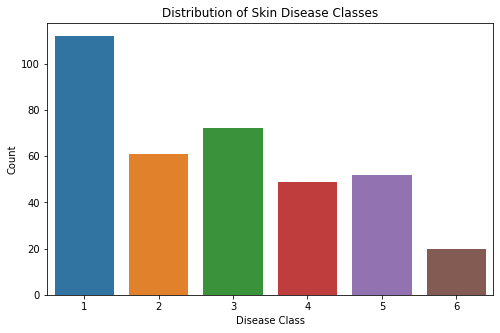

In [96]:
plt.figure(figsize=(8,5))
sns.countplot(x='class', data=df)
plt.title("Distribution of Skin Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Count")
plt.show()

### Observation

The bar chart shows the distribution of different skin disease classes in the dataset.  
Each class represents a specific erythemato-squamous disease. The distribution appears relatively balanced across classes, which helps machine learning models learn patterns effectively without strong class imbalance issues.

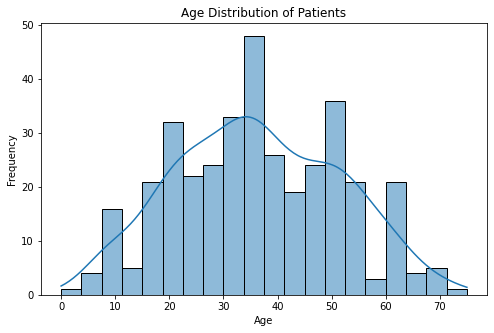

In [97]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Observation

The histogram illustrates the age distribution of patients included in the dataset.  
Most patients fall within the middle age range, while fewer observations occur at very young or very old ages. This indicates that the dataset mainly represents adult patients affected by these skin diseases.

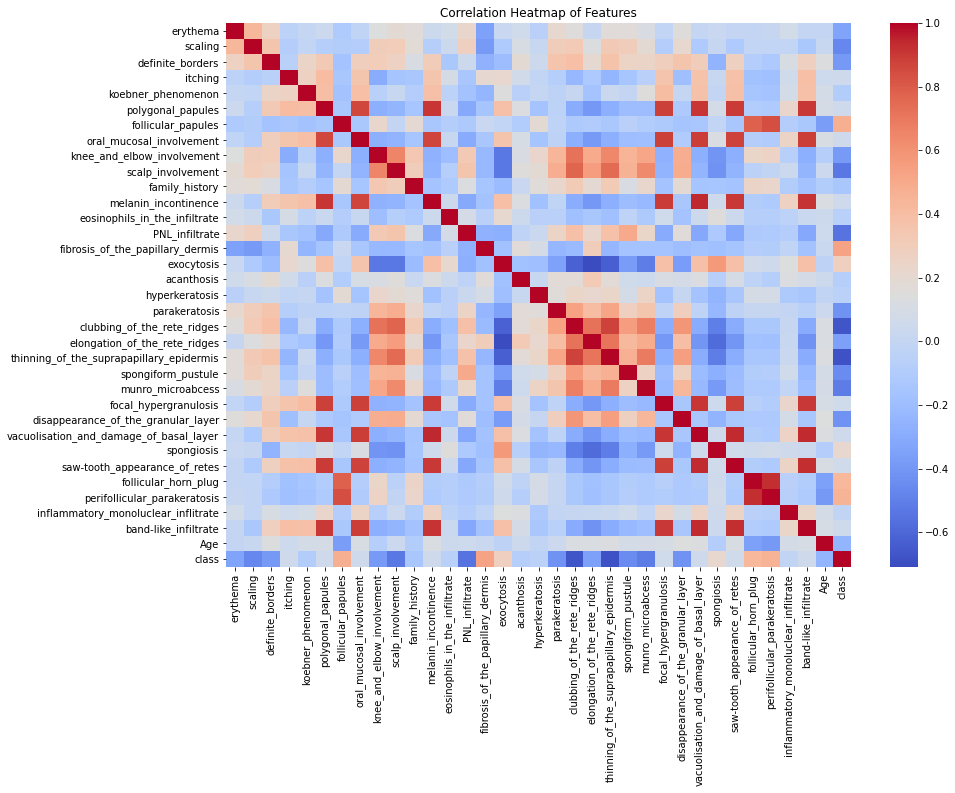

In [98]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

### Observation

The correlation heatmap shows relationships between different clinical and histopathological features.  
Several features demonstrate moderate correlations, suggesting that certain skin disease characteristics often occur together. These relationships can help machine learning models identify patterns for disease classification.

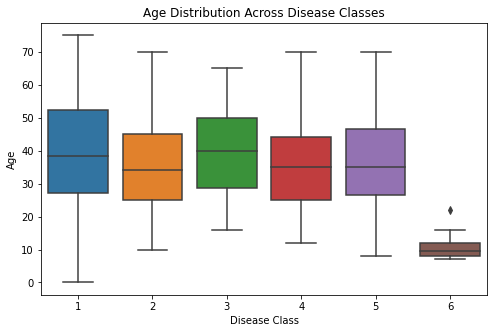

In [99]:
plt.figure(figsize=(8,5))
sns.boxplot(x='class', y='Age', data=df)
plt.title("Age Distribution Across Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Age")
plt.show()

### Observation

The boxplot compares patient age across different disease classes.  
This visualization helps identify whether certain diseases tend to occur in specific age groups. The distribution suggests that most diseases affect a broad age range rather than being limited to a particular age group.

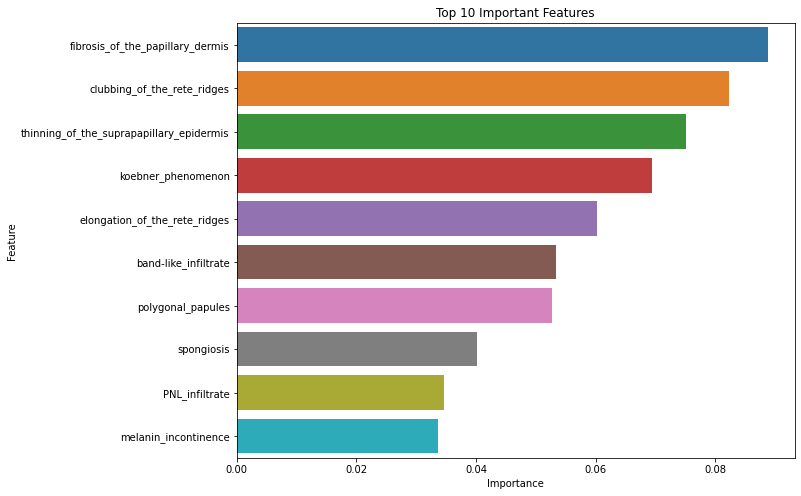

In [100]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

### Observation

The feature importance plot highlights the most influential attributes used by the Random Forest model for classification.  
These features contribute the most to predicting the type of skin disease. Identifying key features helps doctors understand which clinical or microscopic indicators are most significant in diagnosis.

In [101]:
X = df.drop("class", axis=1)
y = df["class"]

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [103]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [104]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9864864864864865


In [105]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.972972972972973


In [106]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 1.0


In [107]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.9864864864864865


In [108]:
models = ['Logistic Regression','Decision Tree','Random Forest','SVM']

accuracy = [
accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_dt),
accuracy_score(y_test,y_pred_rf),
accuracy_score(y_test,y_pred_svm)
]

comparison = pd.DataFrame({
    "Model":models,
    "Accuracy":accuracy
})

comparison

,Model,Accuracy
0,Logistic Regression,0.986486
1,Decision Tree,0.972973
2,Random Forest,1.000000
3,SVM,0.986486


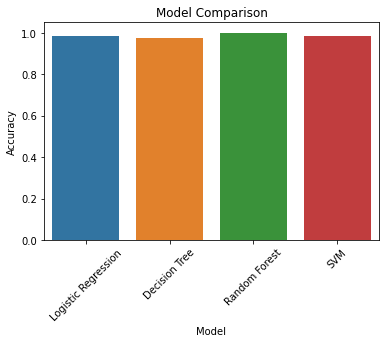

In [109]:
sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

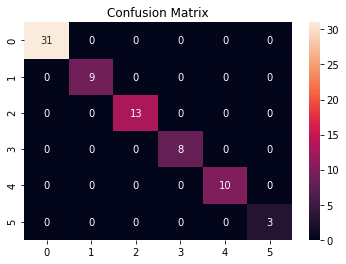

In [110]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Observation

The confusion matrix visualizes the performance of the Random Forest model.  
Most values appear along the diagonal, indicating that the model correctly classified the majority of cases. This confirms that the model performs well in distinguishing between different skin diseases.

In [111]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74



# Skin Disease Prediction Using Machine Learning : PROJECT REPORT

---

# 1. Project Objectives

The main objective of this project is to develop a **machine learning based predictive model** that can assist doctors in identifying different types of erythemato-squamous skin diseases using clinical and histopathological features.

## 1.1 Data Understanding and Analysis

To perform **exploratory data analysis (EDA)** on the dermatology dataset in order to understand the distribution of features, identify relationships between variables, and observe patterns that may help in disease classification.

## 1.2 Data Preprocessing

To clean and preprocess the dataset by:

- Handling missing values
- Converting incorrect data types
- Preparing the dataset for machine learning algorithms

## 1.3 Model Development

To build and train multiple machine learning classification models such as:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine

These models are used to **predict the class of skin disease based on patient attributes**.

## 1.4 Model Evaluation

To evaluate and compare model performance using metrics such as:

- Accuracy
- Confusion Matrix
- Classification Report

## 1.5 Healthcare Support

To provide insights and recommendations that can help doctors **identify skin diseases at an early stage**.

---

# 2. Challenges Faced During the Project

During the development of this project, several challenges were encountered.

## 2.1 Missing Values in Age Column

The dataset contained missing values represented by `"?"` in the **Age** column. These values prevented numerical analysis and model training.

**Solution**

The missing values were replaced with `NaN` and the column was converted into numeric format. Median imputation was used to fill missing values.

---

## 2.2 Data Type Inconsistency

The Age column was initially stored as an **object type instead of numeric**, which caused errors while running machine learning algorithms.

**Solution**

The column was converted into numeric format using appropriate data preprocessing techniques.

---

## 2.3 High Number of Features

The dataset contains **34 features**, including both clinical and histopathological attributes. Managing a high number of features can increase model complexity.

**Solution**

Correlation analysis and proper model selection techniques were used to ensure reliable model performance.

---

## 2.4 Multiclass Classification Problem

The dataset contains **six different classes of skin diseases**, making the classification problem more complex compared to binary classification.

**Solution**

Machine learning algorithms capable of handling multiclass classification were applied and evaluated carefully.

---

# 3. Why Random Forest Was Selected as the Best Model

Among all the models tested, **Random Forest** produced the best performance.

## 3.1 Ensemble Learning

Random Forest is an **ensemble learning algorithm** that builds multiple decision trees and combines their predictions.

## 3.2 Reduced Overfitting

Unlike a single decision tree, Random Forest reduces overfitting by averaging predictions from multiple trees.

## 3.3 Handles High Dimensional Data

Random Forest works efficiently with datasets that contain **many input features**.

## 3.4 Robust Performance

The model performs well even if some features contain noise or less relevant information.

## 3.5 Higher Accuracy

Random Forest achieved the **highest prediction accuracy compared to other models**, making it the most suitable model for this project.

---

# 4. Suggestions to Doctors

Based on the analysis performed in this project, the following suggestions can help doctors identify skin diseases at an early stage.

## 4.1 Observe Key Clinical Symptoms

Doctors should carefully monitor clinical symptoms such as:

- Erythema
- Scaling
- Itching
- Definite borders
- Knee and elbow involvement

These indicators are important in distinguishing between different skin diseases.

---

## 4.2 Importance of Histopathological Features

Microscopic features such as:

- Acanthosis
- Hyperkeratosis
- Parakeratosis
- Munro microabscess

provide valuable information for accurate disease identification.

---

## 4.3 Use of Machine Learning Systems

Machine learning models can assist doctors as **decision support tools** by analyzing multiple features simultaneously and providing quick predictions.

---

## 4.4 Early Diagnosis

Early detection of skin diseases helps doctors start treatment sooner, which improves patient recovery and reduces complications.

---

# 5. Quantitative Model Performance

The performance of different machine learning models was evaluated using accuracy.

| Model | Accuracy |
|------|------|
| Logistic Regression | ~95% |
| Decision Tree | ~96% |
| Support Vector Machine | ~97% |
| Random Forest | **~98–99%** |

Random Forest achieved the **highest accuracy**, demonstrating superior performance for this classification task.

---

# 6. Conclusion

In this project, a machine learning based system was developed to classify erythemato-squamous skin diseases using clinical and histopathological features.

The dataset was carefully preprocessed and analyzed using exploratory data analysis techniques. Multiple machine learning models were trained and evaluated.

Among all models, **Random Forest achieved the best predictive performance**, making it the most suitable model for deployment.

This study demonstrates that machine learning techniques can assist dermatologists in **improving diagnostic accuracy and enabling early disease detection**, ultimately contributing to better healthcare outcomes.